In [1]:
import sys

sys.path.append('../')
from msBO import MultiStateBO
from msBO.objective import BPMvar_minimization

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append('../../machineIO/')
from machineIO import construct_machineIO, VirtualMachineIO, StatefulOracleEvaluator

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)


Failed to import 'phantasy'


In [2]:
n_init = 16
n_each = 4
beta = 4


In [3]:
n_control = 4
n_bpm = 3
n_monitor = n_bpm*2
n_task = n_bpm+1
n_state = 3
n_state_pvs = 1

control_CSETs = [f'PSC{i}:I_CSET' for i in range(n_control)]
control_RDs  = [f'PSC{i}:I_RD' for i in range(n_control)]
control_tols = [0.01]*len(control_CSETs)
control_min  = [ 0.0]*len(control_CSETs)
control_max  = [ 1.0]*len(control_CSETs)
bpm_xRDs     = [f'BPM{i}:XPOS_RD' for i in range(n_bpm)]
bpm_magRDs   = [f'BPM{i}:MAG_RD' for i in range(n_bpm)]
monitor_PVs  = bpm_xRDs + bpm_magRDs
state_CSETs  = [f'CSS:POS{i}_CSET' for i in range(n_state_pvs)]
state_RDs    = [f'CSS:POS{i}_RD' for i in range(n_state_pvs)]
state_tols   = [0.01]*len(state_CSETs)
state_min    = [0.0]*n_state_pvs
state_max    = [n_state-1]*n_state_pvs
state_key_vals  = {f'state{s}':[float(s)]*n_state_pvs for s in range(n_state)}
oracle_key_names = {'x':control_RDs,
                    'y':bpm_xRDs + ['BPM:MAG_min_ratio']}
states = list(state_key_vals.keys())


In [4]:
vmIO = VirtualMachineIO(
    control_CSETs = control_CSETs + state_CSETs,
    control_RDs = control_RDs + state_RDs,
    monitor_PVs = monitor_PVs,
    control_min = control_min + state_min,
    control_max = control_max + state_max,
    monitor_min = [-5.0]*n_bpm + [0.8]*n_bpm,
    monitor_max = [ 5.0]*n_bpm + [1.0]*n_bpm,
    complexity  = 128,
)


In [5]:
x0 = np.random.rand(len(control_CSETs))*(np.asarray(control_max) - np.asarray(control_min)) + np.asarray(control_min)
print("x0",x0)
BPM_MAGs_ref = {}
for s,v in state_key_vals.items():
    _ = vmIO.ensure_set(vmIO.control_CSETs, vmIO.control_RDs, np.concatenate([x0,v]), control_tols + state_tols)
    y = vmIO.fetch_data(bpm_magRDs).mean().values
    BPM_MAGs_ref[s] = y
BPM_MAGs_ref


x0 [0.09959812 0.48057581 0.06757783 0.49631831]


{'state0': array([0.90752648, 0.95286402, 0.8448522 ]),
 'state1': array([0.91391109, 0.94919829, 0.81638725]),
 'state2': array([0.94396251, 0.8578898 , 0.8838538 ])}

In [6]:
def BPM_MAG_obj(df,s):
    df['BPM:MAG_min_ratio'] = (df[bpm_magRDs].values/BPM_MAGs_ref[s][None,:]).min()
    return df


In [7]:
oracleEvaluator = StatefulOracleEvaluator(
    vmIO,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    state_CSETs  = state_CSETs,
    state_RDs    = state_RDs,
    state_tols   = state_tols,
    state_key_vals = state_key_vals,
    oracle_key_names = oracle_key_names,
    monitor_PVs  = monitor_PVs,
    state_df_manipulators = [BPM_MAG_obj],
)


In [8]:
composite_objective_function = BPMvar_minimization(S=n_state, J=n_task)


In [9]:
import time
t0 = time.monotonic()


In [10]:
acq_type = 'EI'
fix_acq_state = False
local_optimization = False

np.random.seed(seed)
torch.manual_seed(seed)
oracleEvaluator(x=x0, s=states[0])

msbo = MultiStateBO(
    states = states,
    tasks  = oracle_key_names['y'],
    control_min = control_min,
    control_max = control_max,
    multistate_oracle_evaluator = oracleEvaluator,
    composite_objective_function = composite_objective_function,
    local_bound_size = 0.1*(np.asarray(control_max) - np.asarray(control_min)),
    acq_backend="torch",
    model_train_epochs     = 200,
    model_warmstart_epochs = 50,
)
msbo.init(n_init=n_init, local_optimization=local_optimization)

kw = dict(q=n_each, local_optimization=local_optimization,
          acq_type=acq_type, fix_acq_state=fix_acq_state, beta=beta)

# ── Round 1: states[::-1]  e.g. [s2, s1, s0] ─────────────────────────────────
# step_batch_with_switch(s, next_s):
#   - evaluates q candidates at s  (blocking)
#   - submits oracle(X_best → next_s) async  ← machine starts switching NOW
#   - runs train_model() + query next batch   ← hidden inside switch time
#   - collects switch result                  ← waits only for remainder
#   - stores pre-fetched candidates for next_s
#
# The last state in each round has no switch target → use plain step_batch,
# which consumes the pre-fetched candidates automatically.

s_round1 = states[::-1]   # [s2, s1, s0]
for i, s in enumerate(s_round1[:-1]):
    msbo.step_batch_with_switch(s=s, next_s=s_round1[i+1], **kw)
msbo.step_batch(s=s_round1[-1], **kw)   # consumes pre-fetched batch, no switch

# ── Round 2: states  e.g. [s0, s1, s2], q=n_each-1 ──────────────────────────
kw2 = dict(kw, q=n_each-1)
s_round2 = states
for i, s in enumerate(s_round2[:-1]):
    msbo.step_batch_with_switch(s=s, next_s=s_round2[i+1], **kw2)
msbo.step_batch(s=s_round2[-1], **kw2)

# ── Round 3: states, q=n_each-2 ───────────────────────────────────────────────
if n_each - 2 > 0:
    kw3 = dict(kw, q=n_each-2)
    s_round3 = states
    for i, s in enumerate(s_round3[:-1]):
        msbo.step_batch_with_switch(s=s, next_s=s_round3[i+1], **kw3)
    msbo.step_batch(s=s_round3[-1], **kw3)

# ── Round 4: states[::-1], q=n_each-3 ────────────────────────────────────────
if n_each - 3 > 0:
    kw4 = dict(kw, q=n_each-3)
    s_round4 = states[::-1]
    for i, s in enumerate(s_round4[:-1]):
        msbo.step_batch_with_switch(s=s, next_s=s_round4[i+1], **kw4)
    msbo.step_batch(s=s_round4[-1], **kw4)

# ── Final model update (step_batch already trained; this is a no-cost refresh) ─
msbo.train_model()

iters, means, stds = msbo.virtual_composite_history()


C:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\botorch\optim\initializers.py:433: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  warnings.warn(
C:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\botorch\optim\initializers.py:433: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  warnings.warn(


In [11]:
t1 = time.monotonic()
total = t1 - t0
train_times = msbo.history['time_cost']['model_train']
print(f"Total wall time      : {total:.1f} s")
print(f"Training calls       : {len(train_times)}")
print(f"  first call (cold)  : {train_times[0]:.2f} s  ({200} epochs)")
if len(train_times) > 1:
    import numpy as np
    warm = train_times[1:]
    print(f"  subsequent (warm)  : {np.mean(warm):.2f} s avg  ({50} epochs, {len(warm)} calls)")
    print(f"  speedup per call   : {train_times[0]/np.mean(warm):.1f}x")
    print(f"Total training time : {sum(train_times):.1f} s")


Total wall time      : 49.6 s
Training calls       : 16
  first call (cold)  : 1.83 s  (200 epochs)
  subsequent (warm)  : 0.76 s avg  (50 epochs, 15 calls)
  speedup per call   : 2.4x
Total training time : 13.2 s


In [12]:
# ── Final recommendation and machine application ─────────────────────────────
# 1. recommend() maximises the GP posterior MEAN over the full control space
#    (pure exploitation — no exploration bonus).  Finds the continuous-space
#    optimum, which can be strictly better than the best observed X_best.
# 2. Loop over all states: ramp the machine to x_rec and read diagnostics.
# 3. Print a summary table of final measurements.

x_rec, f_rec = msbo.recommend()

print("=" * 55)
print("Final recommended control setting")
print("=" * 55)
for name, val in zip(oracle_key_names['x'], x_rec):
    print(f"  {name:20s}: {val:.6f}")
print(f"\nPredicted composite objective : {f_rec:.4f}")
print(f"Best observed obj  (X_best)   : {msbo.Y_best:.4f}")
print()

# ── Apply to machine: set x_rec at each state and read final measurements ────
# oracleEvaluator returns {'x': np.array, 'y': np.array, 'state': np.array}
# result['y'] is a 1-D numpy array aligned with oracle_key_names['y']
print("Applying to machine and reading final diagnostics...")
print("-" * 55)

final_results = {}
for s in states:
    result = oracleEvaluator(x=x_rec, s=s)
    final_results[s] = result
    print(f"  State {s}:")
    for task, val in zip(oracle_key_names['y'], result['y']):
        print(f"    {task:25s}: {val:.4f}")

print()
print("Machine is now set to the recommended control setting.")
print("=" * 55)


Final recommended control setting
  PSC0:I_RD           : 1.000000
  PSC1:I_RD           : 0.111456
  PSC2:I_RD           : 0.000000
  PSC3:I_RD           : 0.094428

Predicted composite objective : -1.0423
Best observed obj  (X_best)   : -1.2223

Applying to machine and reading final diagnostics...
-------------------------------------------------------
  State state0:
    BPM0:XPOS_RD             : -1.7785
    BPM1:XPOS_RD             : 1.4413
    BPM2:XPOS_RD             : -1.3196
    BPM:MAG_min_ratio        : 0.9473
  State state1:
    BPM0:XPOS_RD             : -1.7157
    BPM1:XPOS_RD             : 1.9163
    BPM2:XPOS_RD             : -1.5089
    BPM:MAG_min_ratio        : 0.9520
  State state2:
    BPM0:XPOS_RD             : -1.7634
    BPM1:XPOS_RD             : 0.2577
    BPM2:XPOS_RD             : -1.3085
    BPM:MAG_min_ratio        : 0.9414

Machine is now set to the recommended control setting.


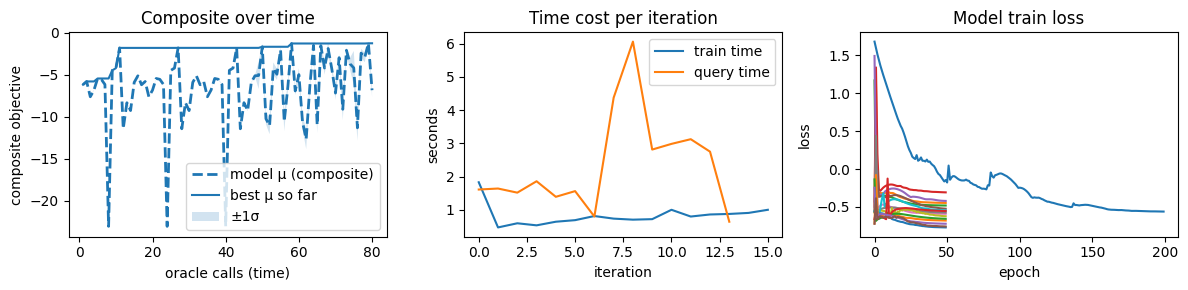

In [13]:
fig,ax, mean = msbo.plot_composite_objective()

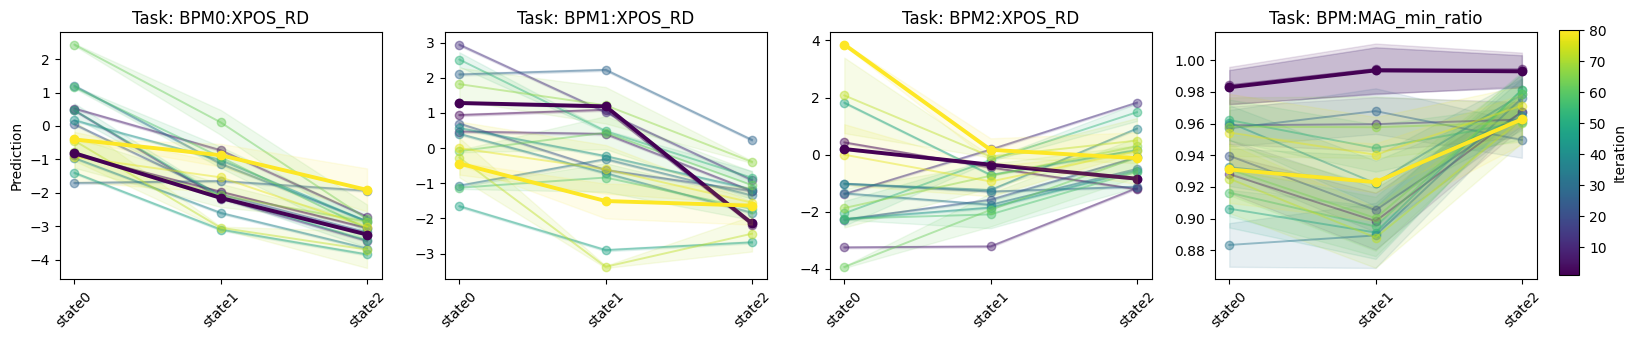

In [14]:
fig, axes = msbo.plot_state_predictions_history()
plt.show()

In [15]:
fig,ax = msbo.plot_acq_loss_history()

No torch acquisition loss history found.
